# Visualizing how we calculate LFP

In [1]:
import numpy as np
import sys
from matplotlib import pyplot as plt
import matplotlib.patches as patches
import scipy
import os
import importlib
import pandas as pd
from sklearn.decomposition import PCA 

sys.path.append('/home/nuttidalab/Documents/renee/spikeRNN/analysis/utils')
import load_data as ld 

2026-02-23 16:50:11.358790: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-02-23 16:50:11.367733: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-02-23 16:50:11.376847: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-02-23 16:50:11.379574: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-02-23 16:50:11.387522: I tensorflow/core/platform/cpu_feature_guar

In [ ]:
model_dir = '/home/nuttidalab/Documents/renee/sternberg/'

model_names = ld.find_files(model_dir, '*.mat')
print(len(model_names))
print(model_names)

13
['/home/nuttidalab/Documents/renee/sternberg/Task_sternberg_N_400_Jitter_5_3_2026_02_15_084724.mat', '/home/nuttidalab/Documents/renee/sternberg/Task_sternberg_N_400_Jitter_5_3_2026_02_14_213742.mat', '/home/nuttidalab/Documents/renee/sternberg/Task_sternberg_N_400_Jitter_5_3_2026_02_13_185831.mat', '/home/nuttidalab/Documents/renee/sternberg/Task_sternberg_N_400_Jitter_5_3_2026_02_15_002559.mat', '/home/nuttidalab/Documents/renee/sternberg/Task_sternberg_N_400_Jitter_5_3_2026_02_14_213423.mat', '/home/nuttidalab/Documents/renee/sternberg/Task_sternberg_N_400_Jitter_5_3_2026_02_16_062747.mat', '/home/nuttidalab/Documents/renee/sternberg/Task_sternberg_N_400_Jitter_5_3_2026_02_15_205451.mat', '/home/nuttidalab/Documents/renee/sternberg/Task_sternberg_N_400_Jitter_5_3_2026_02_15_044336.mat', '/home/nuttidalab/Documents/renee/sternberg/Task_sternberg_N_400_Jitter_5_3_2026_02_15_022733.mat', '/home/nuttidalab/Documents/renee/sternberg/Task_sternberg_N_400_Jitter_5_3_2026_02_14_225313.ma

In [4]:
sys.path.append('/home/nuttidalab/Documents/renee/spikeRNN/rate')
import model

Instructions for updating:
non-resource variables are not supported in the long term


In [16]:
n_trials = 10
eval_amp_threshold = 0.7
matches = [0, 1] # 0 for mismatch, 1 for match
loads = [1, 3] # number of items to remember
model_list = model_names

# delay200
settings = {
        'T': 450, # trial duration (in steps)
        'stim_on': 50, # input stim onset (in steps)
        'stim_dur': 25, # input stim duration (in steps)
        'delay': 200, # delay b/w the two stimuli (in steps)
        'DeltaT': 1, # sampling rate
        'taus': 20, # decay time-constants (in steps)
        'fs': 200,
        'task': 'sternberg', # task name
        'load': 1,
        }



In [17]:
importlib.reload(model)

model_name = os.path.basename(model_names[0])

neural_dict = {
    'r': [],
    'epsp': []
}

bhv_dict = {
    'perf': [],
    'trial_type': []
}

for load in loads:
    settings['load'] = load
    resp_onset = settings['stim_on'] + load*settings['stim_dur'] + settings['delay'] + 10
    for n in range(n_trials):
        u, label = model.generate_input_stim_sternberg(settings)
        trial_type = [load, label]
        # trial_type = np.unique(u, axis=1)[np.where(np.unique(u, axis=1) != 0)]

        _, r, o, epsp = model.eval_tf(model_dir=f'{model_dir}/{model_name}', 
                                        settings=settings, u=u, calc_epsp=True)

        neural_dict['r'].append(r)
        neural_dict['epsp'].append(epsp)
        
        if label == 1:
            if np.max(o[resp_onset:]) > eval_amp_threshold:
                bhv_dict['perf'].append(1)
            else:
                bhv_dict['perf'].append(0)
        else:
            if np.min(o[resp_onset:]) < -eval_amp_threshold:
                bhv_dict['perf'].append(1)
            else:
                bhv_dict['perf'].append(0)

        bhv_dict['trial_type'].append(trial_type)

neural_dict['r'] = np.array(neural_dict['r'])
neural_dict['epsp'] = np.array(neural_dict['epsp'])
bhv_dict['perf'] = np.array(bhv_dict['perf'])


In [19]:
bhv_dict['trial_type']

[[1, -1],
 [1, -1],
 [1, -1],
 [1, 1],
 [1, 1],
 [1, 1],
 [1, 1],
 [1, -1],
 [1, 1],
 [1, 1],
 [3, 1],
 [3, 1],
 [3, 1],
 [3, 1],
 [3, 1],
 [3, 1],
 [3, 1],
 [3, 1],
 [3, -1],
 [3, 1]]

[3 4 5 6 8 9]
[0 1 2 7]
[10 11 12 13 14 15 16 17 19]
[18]


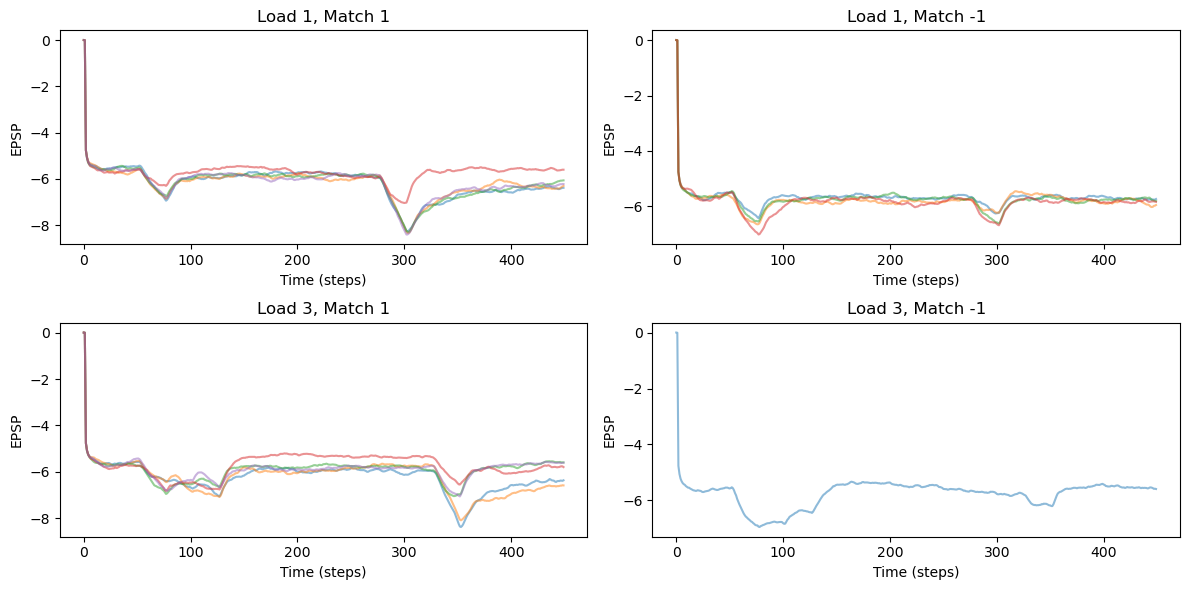

In [21]:
# plot some example epsp traces for each load and trial type
labels = [1, -1]

plt.figure(figsize=(12, 6))
for i, load in enumerate(loads):
    for j, label in enumerate(labels):
        trial_indices = np.where((np.array(bhv_dict['trial_type'])[:,0] == load) & (np.array(bhv_dict['trial_type'])[:,1] == label))[0]
        print(trial_indices)
        plt.subplot(len(loads), len(labels), i*len(labels) + j + 1)
        for idx in trial_indices[:5]: # plot first 5 trials of each type
            plt.plot(neural_dict['epsp'][idx], alpha=0.5)
        plt.title(f'Load {load}, Match {label}')
        plt.xlabel('Time (steps)')
        plt.ylabel('EPSP')
plt.tight_layout()

[3 4 5 6 8 9]
[0 1 2 7]
[10 11 12 13 14 15 16 17 19]
[18]


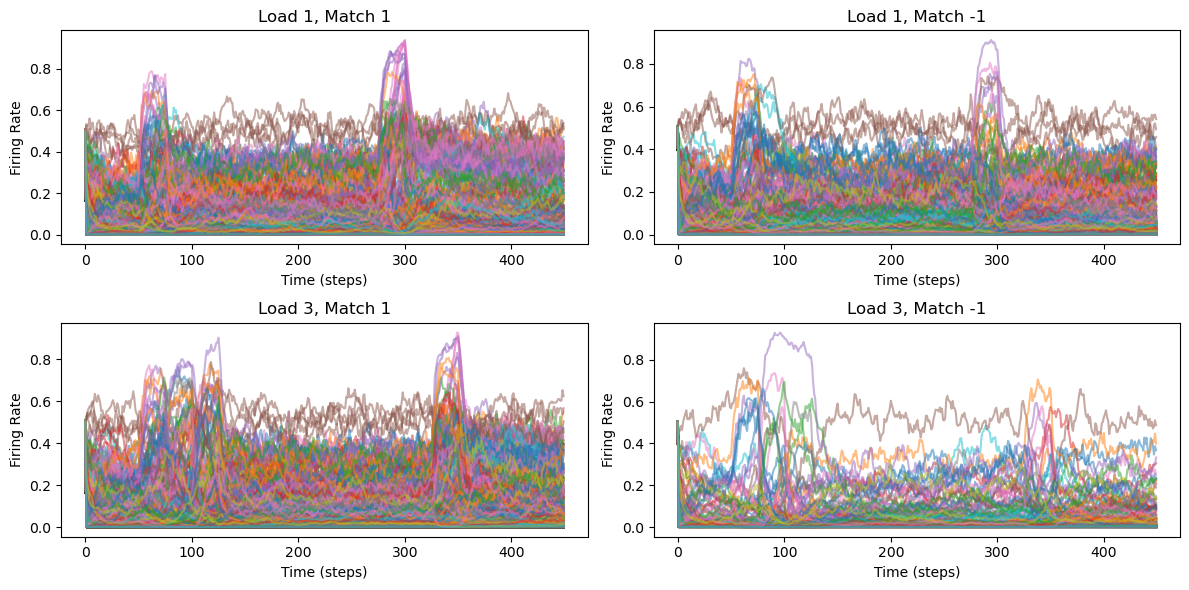

In [22]:
# plot some example firing rate traces for each load and trial type
plt.figure(figsize=(12, 6))
for i, load in enumerate(loads):
    for j, label in enumerate(labels):
        trial_indices = np.where((np.array(bhv_dict['trial_type'])[:,0] == load) & (np.array(bhv_dict['trial_type'])[:,1] == label))[0]
        print(trial_indices)
        plt.subplot(len(loads), len(labels), i*len(labels) + j + 1)
        for idx in trial_indices[:5]: # plot first 5 trials of each type
            plt.plot(neural_dict['r'][idx].T, alpha=0.5) # plot all neurons
        plt.title(f'Load {load}, Match {label}')
        plt.xlabel('Time (steps)')
        plt.ylabel('Firing Rate')
plt.tight_layout()

In [3]:
# load an example model

model_name = model_dirs[0]
print(model_name)

lfp_data, _, _ = ld.load_neural_data(model_name, condn_phrase=condn_phrase, condn_num=delays[1],
                                                  load_LFP=True)

# load timing info
times_fs, times_real, fs_dict = ld.get_times_dict(fs_wanted='ds',condn_phrase=condn_phrase, condn_num=delays[1], model_name=model_name)

Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_231815


In [4]:
lfp_data.shape

(2055, 200, 1000)

In [5]:
exc_ind, inh_ind = ld.get_celltype_label(model_name)

## plot LFP signal

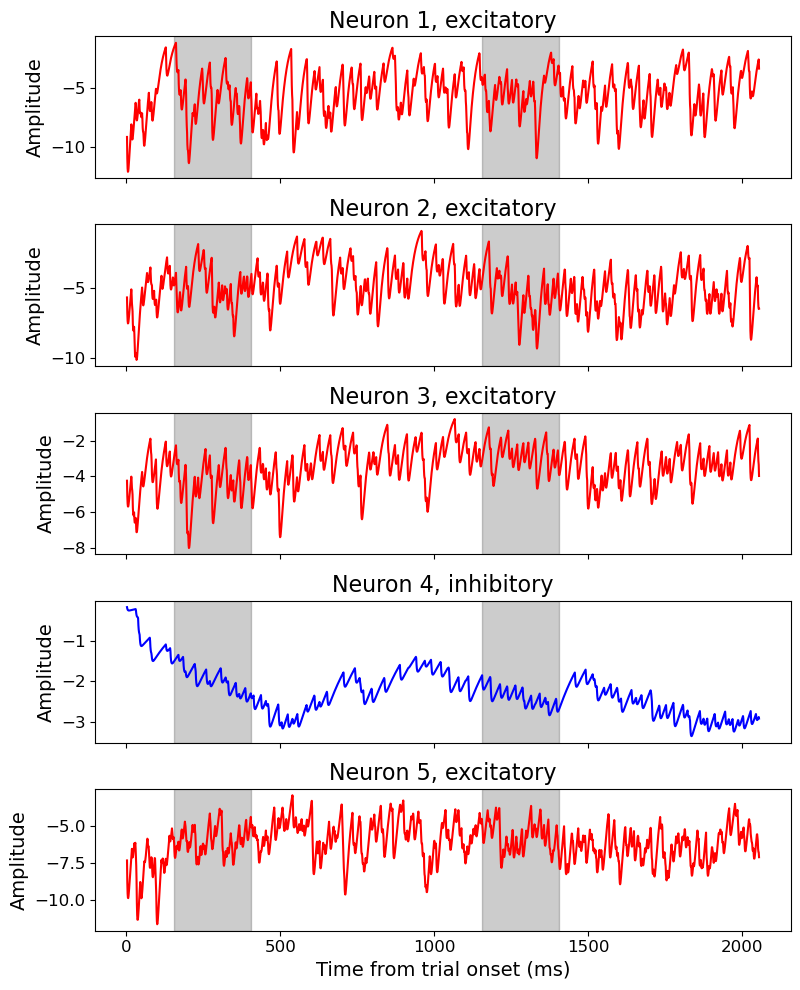

In [7]:
# a few example neurons from one trial

cut_off = 2

fig, axs = plt.subplots(5,1, figsize=(8, 10), sharex=True)
for i in range(5):
    neur_label = ['excitatory' if i in exc_ind else 'inhibitory']
    c = 'r' if i in exc_ind else 'b'
    axs[i].plot(np.arange(cut_off, 2055, 1), lfp_data[cut_off:,i,0], color=c) 
    
    axs[i].axvspan(times_fs['stim1_on'], times_fs['stim1_off'], color='k', alpha=0.2, label='Stim 1')
    axs[i].axvspan(times_fs['stim2_on'], times_fs['stim2_off'], color='k', alpha=0.2, label='Stim 2')
    axs[i].set_title(f'Neuron {i+1}, {neur_label[0]}', fontsize=16)
    
    axs[i].set_ylabel('Amplitude', fontsize=14)
    axs[i].tick_params(axis='both', which='major', labelsize=12)
axs[i].set_xlabel('Time from trial onset (ms)', fontsize=14)
plt.tight_layout()
plt.show()

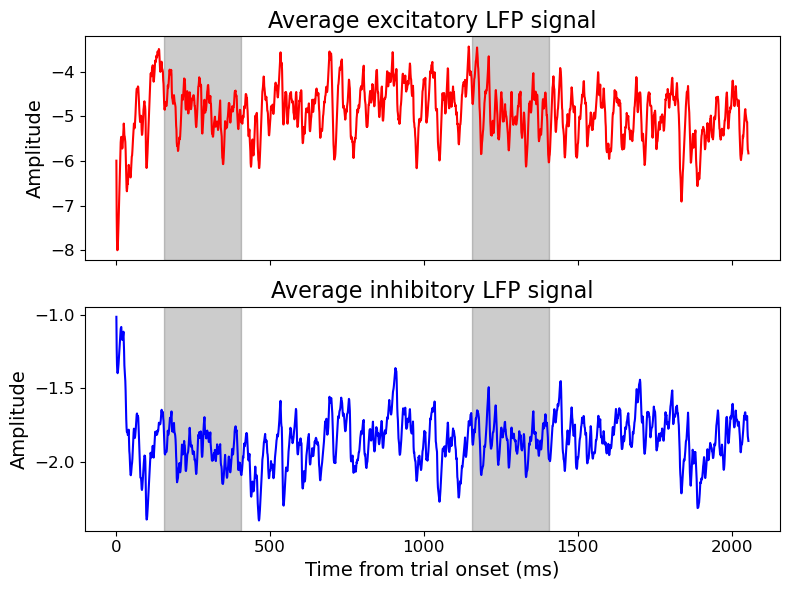

In [9]:
# plot average exc signal and avg inh signal

lfp_exc = np.mean(lfp_data[:, exc_ind, 0], axis=1)
lfp_inh = np.mean(lfp_data[:, inh_ind, 0], axis=1)

cut_off = 2

fig, axs = plt.subplots(2, 1, figsize=(8, 6), sharex=True)
axs[0].plot(np.arange(cut_off, 2055, 1), lfp_exc[cut_off:], color='r')
axs[0].set_title('Average excitatory LFP signal', fontsize=16)
axs[0].set_ylabel('Amplitude', fontsize=14)
axs[0].tick_params(axis='both', which='major', labelsize=12)
axs[0].axvspan(times_fs['stim1_on'], times_fs['stim1_off'], color='k', alpha=0.2, label='Stim 1')
axs[0].axvspan(times_fs['stim2_on'], times_fs['stim2_off'], color='k', alpha=0.2, label='Stim 2')

axs[1].plot(np.arange(cut_off, 2055, 1), lfp_inh[cut_off:], color='b')
axs[1].set_title('Average inhibitory LFP signal', fontsize=16)
axs[1].set_ylabel('Amplitude', fontsize=14)
axs[1].set_xlabel('Time from trial onset (ms)', fontsize=14)
axs[1].tick_params(axis='both', which='major', labelsize=12)
axs[1].axvspan(times_fs['stim1_on'], times_fs['stim1_off'], color='k', alpha=0.2, label='Stim 1')
axs[1].axvspan(times_fs['stim2_on'], times_fs['stim2_off'], color='k', alpha=0.2, label='Stim 2')
plt.tight_layout()
plt.show()

### calc spectrogram

In [13]:
from scipy.signal import spectrogram, resample, iirnotch, filtfilt


In [10]:
# plot spectrogram

def calc_trial_spect(signal, fs, nperseg, noverlap, nfft, f_cutoff =0,
                     plot=1, stim1_on=0, stim1_off=0, stim2_on=0, stim2_off=0,
                     signal_label = 'scalp EEG', spect_range = [],
                     t_skip=5, f_skip=2, plot_range = []):
    # Calculate the spect for a single trial (or mean of trial types if signal has multiple trials)
    # Signal is trials x time

    f, t, s = spectrogram(signal, fs=fs, window=('tukey', 0.25),
                          nperseg=nperseg, noverlap=noverlap, nfft=nfft, scaling='density') 
    
    if len(s.shape) > 2:
        s = np.nanmean(s, axis=0)
    
    if f_cutoff == 0:
            f_cutoff_idx = len(f)
    else:
        f_cutoff_idx = np.where(f <= f_cutoff)[0][-1]
    
    if plot:
        # fft_times = {
        #     'stim1_on_idx': np.where(t <= stim1_on)[0][-1],
        #     'stim1_off_idx': np.where(t <= stim1_off)[0][-1],
        #     'stim2_on_idx': np.where(t <= stim2_on)[0][-1],
        #     'stim2_off_idx': np.where(t <= stim2_off)[0][-1],
        # }
        # fs_times = ld.get_event_indices(fs)

        # fig, axs = plt.subplots(3,1,figsize=(16,14))

        # # plot raw signal
        # axs[0].plot(signal)
        # axs[0].set_title(f'{signal_label} signal')
        # for key in fs_times:
        #     axs[0].axvline(x=fs_times[key], color='r', linestyle='--')
        
        fig, ax = plt.subplots(1, 1, figsize=(8, 4))
        
        t = t * 1000  # convert to ms
        # fix the fft_times to be in ms
        times = {
            'stim1_on': stim1_on,
            'stim1_off': stim1_off,
            'stim2_on': stim2_on,
            'stim2_off': stim2_off,
        }
        
        # plot spectrogram
        if len(spect_range) > 0:
            im = ax.imshow(10*np.log(s[:f_cutoff_idx,:]), 
                                aspect='auto', origin='lower', vmin=spect_range[0], vmax=spect_range[1],
                                extent=[t[0], t[-1], f[0], f[f_cutoff_idx-1]])
        else:
            im = ax.imshow(10*np.log(s[:f_cutoff_idx,:]), 
                                aspect='auto', origin='lower',
                                extent=[t[0], t[-1], f[0], f[f_cutoff_idx-1]])
        ax.set_xlabel('time (ms)', fontsize=14)
        # ax.set_xticks(np.arange(0, len(t), t_skip), np.round(t[::t_skip], 3)*1000)
        # set x ticks at fixed increments
        # x_range = np.arange(0,len(t))
        ax.set_xticks(np.arange(0,2001,500), np.arange(0,2001,500), fontsize=12)
        ax.set_ylabel('frequency (Hz)', fontsize=14)
        ax.set_yticks(range(len(f[:f_cutoff_idx]))[::f_skip],f[:f_cutoff_idx][::f_skip], fontsize=12)
        cbar = fig.colorbar(im)
        cbar.ax.set_title('dB/Hz')
        # ax.set_title(f'Time-Frequency plot, nperseg={nperseg}, noverlap={noverlap}, nfft={nfft}')
        for key in times:
            ax.axvline(x=times[key], color='r', linestyle='--', label=key)
        # ax.legend()

    return f[:f_cutoff_idx], t, s[:f_cutoff_idx,:], ax



In [11]:
nperseg=50
noverlap = nperseg//1.2
nfft = nperseg*20

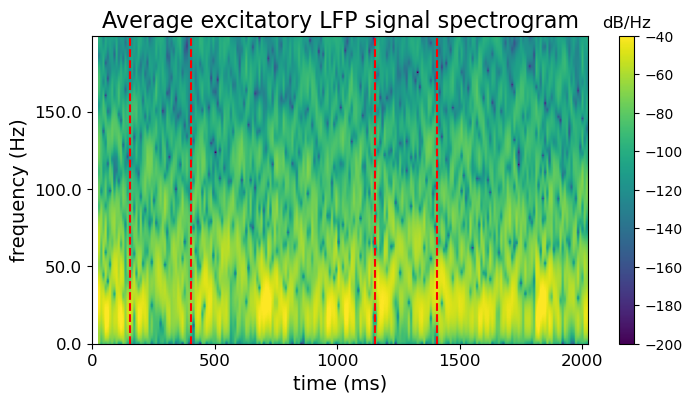

In [14]:
f, t, s, ax = calc_trial_spect(lfp_exc, fs_dict['ds'], nperseg, noverlap, nfft,
                           f_cutoff=200, plot=1, stim1_on=times_fs['stim1_on'],
                            stim1_off=times_fs['stim1_off'], stim2_on=times_fs['stim2_on'],
                            stim2_off=times_fs['stim2_off'], spect_range=[-200,-40],
                            t_skip=20, f_skip=50, plot_range=[0, 2055],)
# ax.set_ylim([0,400]);
ax.set_title('Average excitatory LFP signal spectrogram', fontsize=16);
plt.show()

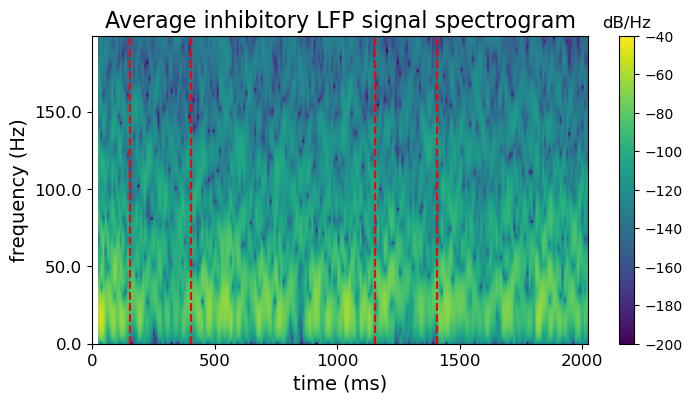

In [16]:
f, t, s, ax = calc_trial_spect(lfp_inh, fs_dict['ds'], nperseg, noverlap, nfft,
                           f_cutoff=200, plot=1, stim1_on=times_fs['stim1_on'],
                            stim1_off=times_fs['stim1_off'], stim2_on=times_fs['stim2_on'],
                            stim2_off=times_fs['stim2_off'], spect_range=[-200,-40],
                            t_skip=20, f_skip=50, plot_range=[0, 2055],)
# ax.set_ylim([0,400]);
ax.set_title('Average inhibitory LFP signal spectrogram', fontsize=16);
plt.show()